# Function Transformation

In [1]:
%pip install uv
%uv venv
%uv pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


Using CPython 3.13.1 interpreter at: C:\Users\Ishaan Rastogi\AppData\Local\Programs\Python\Python313\python.exe
Creating virtual environment at: .venv
error: Failed to create virtual environment
  Caused by: A virtual environment already exists at `.venv`. Use `--clear` to replace it


Note: you may need to restart the kernel to use updated packages.


Using Python 3.13.1 environment at: C:\Users\Ishaan Rastogi\AppData\Local\Programs\Python\Python313
Checked 7 packages in 50ms


In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [3]:
df = pd.read_csv('datasets/loan.csv')
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


C:\Users\Ishaan Rastogi\AppData\Local\Temp\ipykernel_2794332\71723079.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df["CoapplicantIncome"])


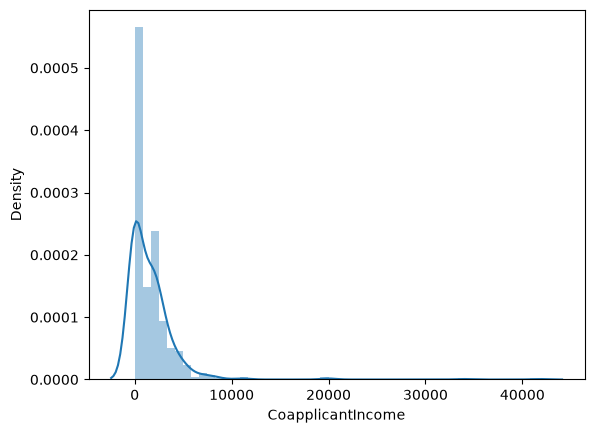

In [4]:
sns.distplot(df["CoapplicantIncome"])
plt.show()

In [5]:
q1 = df["CoapplicantIncome"].quantile(0.25)
q3 = df["CoapplicantIncome"].quantile(0.75)
iqr = q3-q1

min_r = q1-(1.5*iqr)
max_r = q3+(1.5*iqr)
min_r,max_r

(np.float64(-3445.875), np.float64(5743.125))

C:\Users\Ishaan Rastogi\AppData\Local\Temp\ipykernel_2794332\904101699.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df["CoapplicantIncome"])


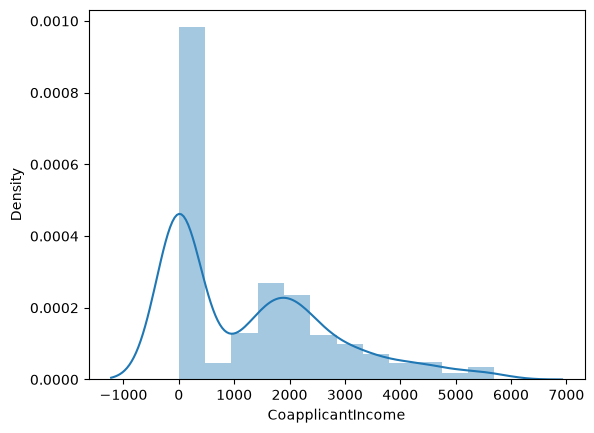

In [6]:
df = df[df["CoapplicantIncome"] < max_r]
sns.distplot(df["CoapplicantIncome"])
plt.show()

In [10]:
from sklearn.preprocessing import FunctionTransformer
ft = FunctionTransformer(np.log1p, validate=True)
df["CoappIncome_tf"] = ft.fit_transform(df[["CoapplicantIncome"]])
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,CoappIncome_tf
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y,0.000000
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N,7.319202
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y,0.000000
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y,7.765993
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y,0.000000


`Comparision`

C:\Users\Ishaan Rastogi\AppData\Local\Temp\ipykernel_2794332\3443168951.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df["CoapplicantIncome"])
C:\Users\Ishaan Rastogi\AppData\Local\Temp\ipykernel_2794332\3443168951.py:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df["CoappIncome_tf"])


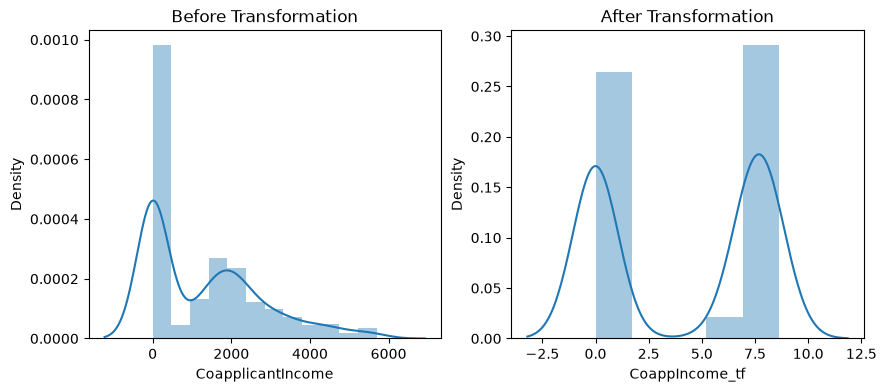

In [12]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
sns.distplot(df["CoapplicantIncome"])
plt.title("Before Transformation")

plt.subplot(1,2,2)
sns.distplot(df["CoappIncome_tf"])
plt.title("After Transformation")
plt.show()

## Checking with outliers present

In [14]:
df1 = pd.read_csv('datasets/loan.csv')

In [15]:
from sklearn.preprocessing import FunctionTransformer
ft = FunctionTransformer(np.log1p, validate=True)
df1["CoappIncome_tf"] = ft.fit_transform(df1[["CoapplicantIncome"]])
df1.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,CoappIncome_tf
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y,0.000000
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N,7.319202
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y,0.000000
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y,7.765993
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y,0.000000


C:\Users\Ishaan Rastogi\AppData\Local\Temp\ipykernel_2794332\3834982641.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df1["CoapplicantIncome"])
C:\Users\Ishaan Rastogi\AppData\Local\Temp\ipykernel_2794332\3834982641.py:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df1["CoappIncome_tf"])

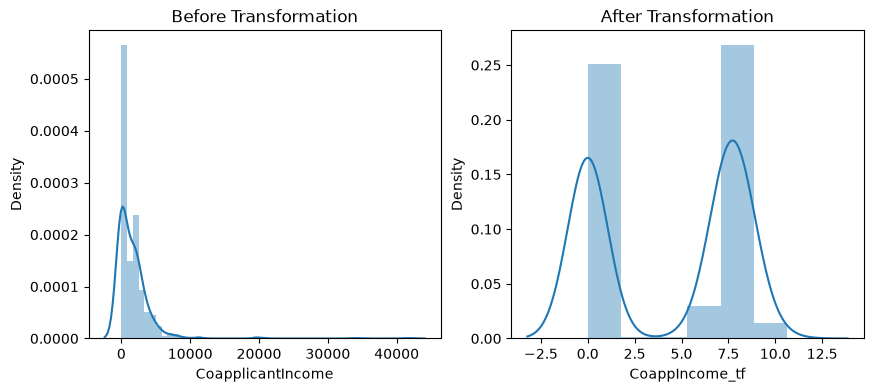

In [17]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
sns.distplot(df1["CoapplicantIncome"])
plt.title("Before Transformation")

plt.subplot(1,2,2)
sns.distplot(df1["CoappIncome_tf"])
plt.title("After Transformation")
plt.show()

# x2

In [18]:
from sklearn.preprocessing import FunctionTransformer
ft2 = FunctionTransformer(lambda x : x**2, validate=True)
df1["CoappIncome_tf1"] = ft2.fit_transform(df1[["CoapplicantIncome"]])
df1.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,CoappIncome_tf,CoappIncome_tf1
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y,0.000000,0.0
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N,7.319202,2274064.0
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y,0.000000,0.0
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y,7.765993,5560164.0
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y,0.000000,0.0


C:\Users\Ishaan Rastogi\AppData\Local\Temp\ipykernel_2794332\1423158926.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df1["CoapplicantIncome"])
C:\Users\Ishaan Rastogi\AppData\Local\Temp\ipykernel_2794332\1423158926.py:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df1["CoappIncome_tf1"]

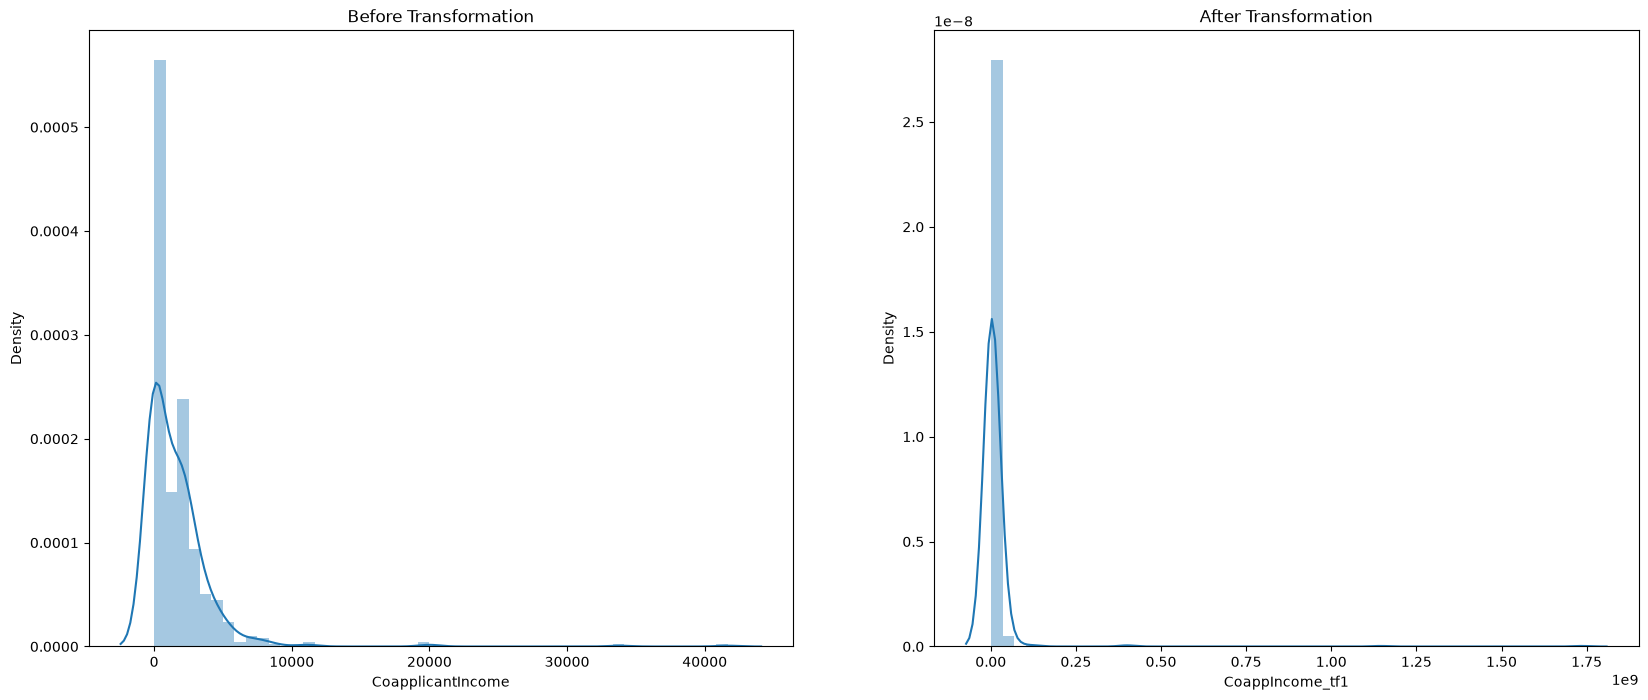

In [21]:
plt.figure(figsize=(20,8))
plt.subplot(1,2,1)
sns.distplot(df1["CoapplicantIncome"])
plt.title("Before Transformation")

plt.subplot(1,2,2)
sns.distplot(df1["CoappIncome_tf1"])
plt.title("After Transformation")
plt.show()